### etd-rk4.ipynb
*Created June 16, 2026* <br/> 
This notebook implements the ETD-RK4 method, a fourth-order exponential time differencing (ETD) method for solving stiff ODE systems. 



In [1]:
using CairoMakie, OrdinaryDiffEq, LinearAlgebra, NBInclude, UnPack, Statistics, Random
@nbinclude("../set_makie_defaults.ipynb")
@nbinclude("phi_functions.ipynb")

In [2]:
function etd_rk4(A, f, u0; tspan, Δt, p = nothing)
    """
    Solves ODE system of the form du/dt = Au + f(u,p,t) for t ∈ [tspan[1],tspan[2]]
    using a fourth-order exponential time differencing (ETD) scheme. 
    
    PARAMETERS
    ----------
    A :: N x N matrix (or scalar) 
    f :: nonlinear function of the form f(u,p,t)
    u0 :: initial condition (length N vector, or a scalar)
    tspan :: time interval over which to integrate
    Δt :: time step (fixed) 
    p :: parameter for nonlinear function (if required)

    RETURNS
    -------
    sol = (u = u, t = t, p = p, Δt = Δt)

        sol.u :: vector of the solution iterates 
        sol.t :: vector of the time values corresponding to solution iterates
        Δt    :: the time step size 
        p     :: parameter for f 
    """

    t0, tf = tspan
    nsteps = Int(round((tf - t0) / Δt))
    t = collect(range(t0, step = Δt, length = nsteps + 1))
    u = [zero(u0) for _ in 1:nsteps + 1]
    u[1] = u0

    #Precompute some matrices 
    Z = A*Δt
    Z_half = 0.5*A*Δt

    Φ₀, Φ₁, Φ₂, Φ₃ = phis(Z, 3)
    Φ₀_half, Φ₁_half = phis(Z_half, 1)

    B₁ =   Φ₁ -  3*Φ₂ + 4*Φ₃
    B₂ =         2*Φ₂ - 4*Φ₃
    B₃ =         2*Φ₂ - 4*Φ₃   
    B₄ =      -  1*Φ₂ + 4*Φ₃

    for n = 1:nsteps #compute u[2] through u[nsteps + 1] 

        #Initial nonlinear eval
        Fn = f(u[n], p, t[n]) 

        #Half-step prediction
        a = Φ₀_half * u[n]   +   0.5 * Δt * Φ₁_half * Fn
        Fa = f(a, p, t[n] + Δt/2)

        #Second half-step prediction
        b = Φ₀_half * u[n]   +   0.5 * Δt * Φ₁_half * Fa
        Fb = f(b, p, t[n] + Δt/2)

        #Full-step prediction 
        c = Φ₀_half * a      +   0.5 * Δt * Φ₁_half * (2*Fb - Fn)
        Fc = f(c, p, t[n] + Δt)

        #Final update 
        u[n+1] = Φ₀ * u[n]   +   Δt * B₁ * Fn  +  Δt * B₂ * (Fa + Fb)  +  Δt * B₄ * Fc 
    end 

    return (u = u, t = t, Δt = Δt, p = p)
end 

etd_rk4 (generic function with 1 method)

In [245]:
# #Test ETD Euler using a *scalar* equation
# function u_exact(t,p)
#     @unpack a, u0 = p 
#     return a ./ (1.0 - (1.0 - a/u0)*exp(a*t))
# end 

# a = 3.0
# u0 = 1.0
# p = (a = a, u0 = u0)
# f(u,p,t) = u^2 
# @time sol = etd_rk4(-a, f, u0 = 1.0; Δt = 0.01, tspan = (0,3.0), p = p);

# t = sol.t
# u_num = sol.u;

  0.056535 seconds (55.31 k allocations: 2.704 MiB, 99.83% compilation time: 100% of which was recompilation)


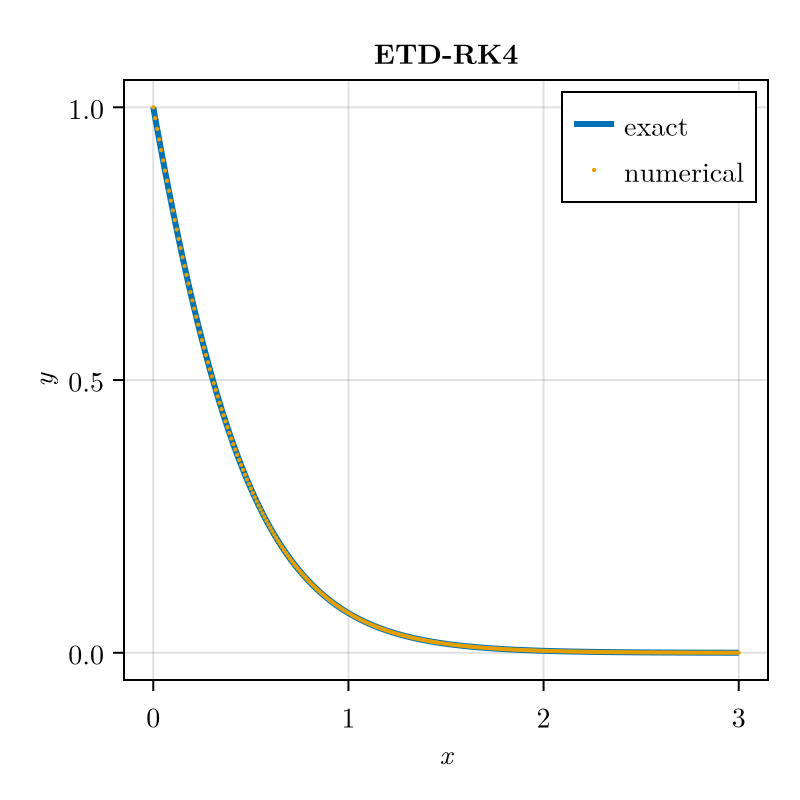

CairoMakie.Screen{IMAGE}


In [247]:
# fig = Figure(size = (400,400))
# ax = Axis(fig[1,1], xlabel = L"x", ylabel = L"y", title = "ETD-RK4")

# u_ex = u_exact.(t, Ref(p));
# lines!(t, u_ex, label = "exact", linewidth = 3, color = Cycled(1))
# scatter!(t, u_num, label = "numerical", markersize = 3, color = Cycled(2))

# axislegend(ax, position = :rt)
# display(fig)

In [3]:
#TESTING OUT ETD-RK2 using a system of 2 equations 
A = [-100.0 0.0; 0.0 -1.0]
u0 = [0.0, 1.0]

function f(u,p,t)
    f1 = cos(t) + 100*sin(t) + (u[1])^2 - (sin(t))^2 
    f2 = -sin(t) + cos(t) + u[1] * u[2] - sin(t) * cos(t)
    return [f1, f2]
end 

u_exact(t) = [sin(t), cos(t)]

@time out = etd_rk4(A, f, u0; tspan = (0, 3.0), Δt = 0.05, p = 1);

  6.354033 seconds (5.29 M allocations: 266.329 MiB, 6.94% gc time, 99.92% compilation time)
